# Clase 4B — Funciones de Respuesta en Frecuencia (FRF)

## Inspirado en Tom Irvine: *An Introduction to Frequency Response Functions*

En este cuadernillo estudiaremos las funciones de respuesta en frecuencia de un sistema de un grado de libertad (SDOF).

El objetivo es conectar:

- la ecuación diferencial del sistema masa–resorte–amortiguador,
- la Transformada de Fourier,
- la función de respuesta en frecuencia,
- magnitud y fase,
- y las distintas formas de FRF usadas en vibraciones.

Trabajaremos con seis funciones principales:

1. **Admittance / Receptance**: desplazamiento / fuerza  
2. **Mobility**: velocidad / fuerza  
3. **Accelerance**: aceleración / fuerza  
4. **Dynamic stiffness**: fuerza / desplazamiento  
5. **Mechanical impedance**: fuerza / velocidad  
6. **Apparent mass**: fuerza / aceleración

## 1. Sistema masa–resorte–amortiguador

Consideramos un sistema de un grado de libertad:

$
m\ddot{x}(t)+c\dot{x}(t)+kx(t)=f(t)
$

donde:

- $m$: masa $[kg]$
- $c$: coeficiente de amortiguamiento viscoso $[N\,s/m]$
- $k$: rigidez $[N/m]$
- $x(t)$: desplazamiento $[m]$
- $f(t)$: fuerza externa $[N]$

La frecuencia natural angular es:

$
\omega_n=\sqrt{\frac{k}{m}}
$

y la frecuencia natural en Hertz es:

$
f_n=\frac{\omega_n}{2\pi}
$

El factor de amortiguamiento es:

$
\zeta=\frac{c}{2m\omega_n}
$

In [1]:
# =========================================================
# 1. Importar librerías
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

## 2. Propiedad de Fourier para derivadas

Para pasar desde la ecuación diferencial al dominio de la frecuencia usamos una propiedad fundamental de la Transformada de Fourier.

Si:

$
x(t) \longleftrightarrow X(\omega)
$

entonces:

$
\frac{dx(t)}{dt} \longleftrightarrow j\omega X(\omega)
$

y:

$
\frac{d^2x(t)}{dt^2} \longleftrightarrow (j\omega)^2X(\omega)
$

Como:

$
(j\omega)^2=-\omega^2
$

entonces:

$
\ddot{x}(t)\longleftrightarrow -\omega^2X(\omega)
$

## 3. Derivación de la FRF de desplazamiento

Partimos de:

$
m\ddot{x}(t)+c\dot{x}(t)+kx(t)=f(t)
$

Aplicando Transformada de Fourier:

$
m(-\omega^2)X(\omega)+c(j\omega)X(\omega)+kX(\omega)=F(\omega)
$

Factorizando:

$
\left(k-m\omega^2+jc\omega\right)X(\omega)=F(\omega)
$

Por lo tanto:

$
H_x(\omega)=\frac{X(\omega)}{F(\omega)}=
\frac{1}{k-m\omega^2+jc\omega}$

Esta función se conoce como:

- **Admittance**
- **Compliance**
- **Receptance**

y representa la respuesta de desplazamiento por unidad de fuerza.

## 4. Parámetros del ejemplo

Usaremos los mismos parámetros del ejemplo de Irvine:

$
m=1 \; kg
$

$
f_n=100 \; Hz
$

$
\zeta=0.05
$

A partir de estos valores calculamos:

$
\omega_n = 2\pi f_n
$

$
k=m\omega_n^2
$

$
c=2\zeta m\omega_n
$

In [7]:
# =========================================================
# 2. Parámetros del sistema
# =========================================================

m = 1.0          # masa [kg]
fn = 100.0       # frecuencia natural [Hz]
zeta = 0.05      # razón de amortiguamiento

wn = 2 * np.pi * fn
k = m * wn**2
c = 2 * zeta * m * wn

print(f"m = {m:.1f} kg")
print(f"fn = {fn:.1f} Hz")
print(f"wn = {wn:.1f} rad/s")
print(f"k = {k:.1e} N/m")
print(f"c = {c:.1f} N s/m")
print(f"zeta = {zeta:.3f}")

m = 1.0 kg
fn = 100.0 Hz
wn = 628.3 rad/s
k = 3.9e+05 N/m
c = 62.8 N s/m
zeta = 0.050


## 5. Eje de frecuencia

Para reproducir el estilo de gráficos de Irvine, usaremos un eje logarítmico entre 1 Hz y 1000 Hz.

Esto permite observar:

- la zona de baja frecuencia,
- la región de resonancia,
- y la zona de alta frecuencia.

In [8]:
# =========================================================
# 3. Eje de frecuencia
# =========================================================

f = np.logspace(0, 3, 3000)  # 1 Hz a 1000 Hz
w = 2 * np.pi * f

## 6. Cálculo de las seis FRF

A partir de la receptancia:

$
H_x(\omega)=\frac{X(\omega)}{F(\omega)}
$

podemos obtener:

### Movilidad

$
H_v(\omega)=\frac{V(\omega)}{F(\omega)}=j\omega H_x(\omega)
$

### Acelerancia

$
H_a(\omega)=\frac{A(\omega)}{F(\omega)}=-\omega^2H_x(\omega)
$

Y sus inversas:

### Rigidez dinámica

$
K_d(\omega)=\frac{F(\omega)}{X(\omega)}=\frac{1}{H_x(\omega)}
$

### Impedancia mecánica

$
Z(\omega)=\frac{F(\omega)}{V(\omega)}=\frac{1}{H_v(\omega)}
$

### Masa aparente

$
M_a(\omega)=\frac{F(\omega)}{A(\omega)}=\frac{1}{H_a(\omega)}
$

In [9]:
# =========================================================
# 4. Cálculo de FRF complejas
# =========================================================

# Receptancia / admittance: displacement / force
Hx = 1 / (k - m*w**2 + 1j*c*w)

# Mobility: velocity / force
Hv = 1j * w * Hx

# Accelerance: acceleration / force
Ha = -w**2 * Hx

# Inverse FRFs
Kd = 1 / Hx   # Dynamic stiffness: force / displacement
Z  = 1 / Hv   # Mechanical impedance: force / velocity
Ma = 1 / Ha   # Apparent mass: force / acceleration

## 7. Función auxiliar para graficar magnitud y fase

Las FRF son funciones complejas. Por eso se representan normalmente mediante:

- **magnitud**
- **fase**

En estos gráficos:

- la magnitud se grafica en escala log-log,
- la fase se grafica en escala semilogarítmica,
- y la frecuencia se expresa en Hz.

In [25]:
# =========================================================
# 5. Función auxiliar de gráficos
# =========================================================

def plot_frf_pair(
    f,
    H,
    title,
    ylabel_mag,
    phase_ylim=None,
    mag_ylim=None,
    phase_convention="lag"
):
    """
    Grafica magnitud y fase de una función de respuesta en frecuencia.

    phase_convention:
    - "lag": grafica el ángulo de atraso, estilo Irvine.
    - "angle": grafica el ángulo complejo directo de H.
    """

    magnitude = np.abs(H)

    # Fase continua en grados
    phase_unwrapped = np.unwrap(np.angle(H)) * 180 / np.pi

    if phase_convention == "lag":
        # Ángulo de atraso: respuesta atrasada respecto de la entrada
        phase_plot = np.mod(-phase_unwrapped, 360)

    elif phase_convention == "angle":
        # Ángulo complejo directo
        phase_plot = np.mod(phase_unwrapped, 360)

    else:
        raise ValueError("phase_convention debe ser 'lag' o 'angle'")

    # -----------------------------
    # Gráfico de fase
    # -----------------------------
    plt.figure(figsize=(8, 4))
    plt.semilogx(f, phase_plot)
    plt.title(f"{title} — Phase")
    plt.xlabel("Excitation frequency [Hz]")
    plt.ylabel("Phase [degrees]")
    plt.grid(True, which="both", linestyle=":")

    if phase_ylim is not None:
        plt.ylim(*phase_ylim)

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Gráfico de magnitud
    # -----------------------------
    plt.figure(figsize=(8, 4))
    plt.loglog(f, magnitude)
    plt.title(f"{title} — Magnitude")
    plt.xlabel("Excitation frequency [Hz]")
    plt.ylabel(ylabel_mag)
    plt.grid(True, which="both", linestyle=":")

    if mag_ylim is not None:
        plt.ylim(*mag_ylim)

    plt.tight_layout()
    plt.show()

## 8. Admittance / Receptance


La **admittance** o **receptance** es:

$
\frac{X(\omega)}{F(\omega)}
$

Representa desplazamiento por unidad de fuerza.

Unidad:

$
m/N
$

Cerca de la frecuencia natural aparece un máximo en la magnitud.

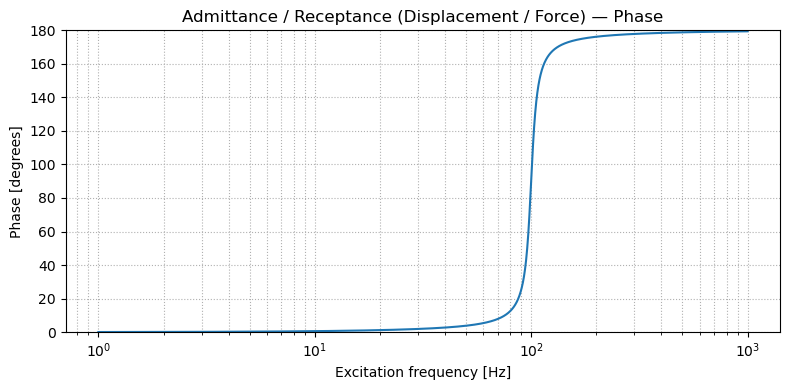

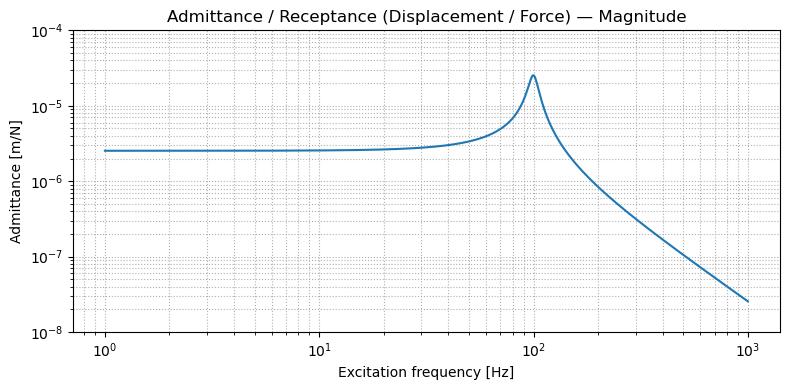

In [26]:
plot_frf_pair(
    f,
    Hx,
    title="Admittance / Receptance (Displacement / Force)",
    ylabel_mag="Admittance [m/N]",
    phase_ylim=(0, 180),
    mag_ylim=(1e-8, 1e-4),
    phase_convention="lag"
)

## 9. Mobility


La **mobility** es:

$
\frac{V(\omega)}{F(\omega)}
$

Representa velocidad por unidad de fuerza.

Unidad:

$
(m/s)/N
$

Se obtiene multiplicando la receptancia por $j\omega$.

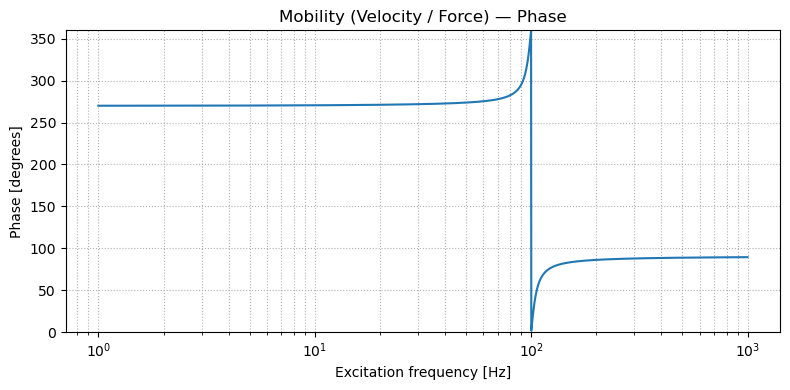

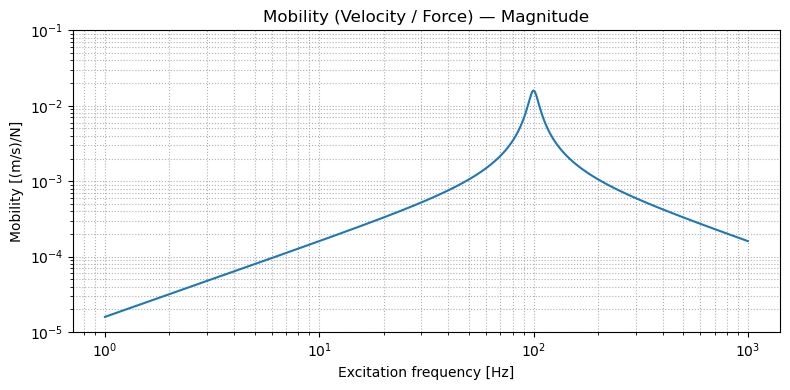

In [27]:
plot_frf_pair(
    f,
    Hv,
    title="Mobility (Velocity / Force)",
    ylabel_mag="Mobility [(m/s)/N]",
    phase_ylim=(0, 360),
    mag_ylim=(1e-5, 1e-1),
    phase_convention="lag"
)

## 10. Accelerance


La **accelerance** o **inertance** es:

$
\frac{A(\omega)}{F(\omega)}
$

Representa aceleración por unidad de fuerza.

Unidad:

$
(m/s^2)/N
$

Se obtiene multiplicando la receptancia por $-\omega^2$.

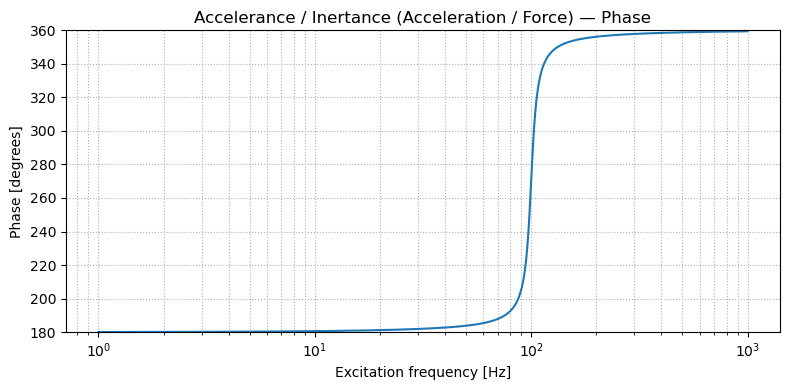

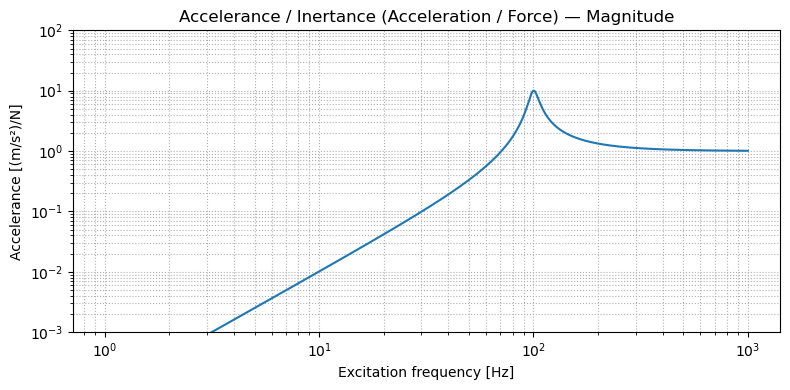

In [28]:
plot_frf_pair(
    f,
    Ha,
    title="Accelerance / Inertance (Acceleration / Force)",
    ylabel_mag="Accelerance [(m/s²)/N]",
    phase_ylim=(180, 360),
    mag_ylim=(1e-3, 1e2),
    phase_convention="lag"
)

## 11. Dynamic Stiffness


La **dynamic stiffness** es la inversa de la receptancia:

$
\frac{F(\omega)}{X(\omega)}
$

Unidad:

$
N/m
$

En baja frecuencia, tiende a la rigidez estática $k$. Cerca de la resonancia presenta un mínimo.

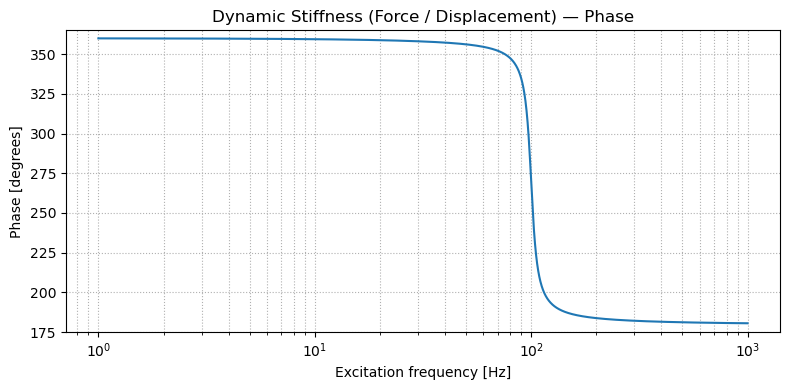

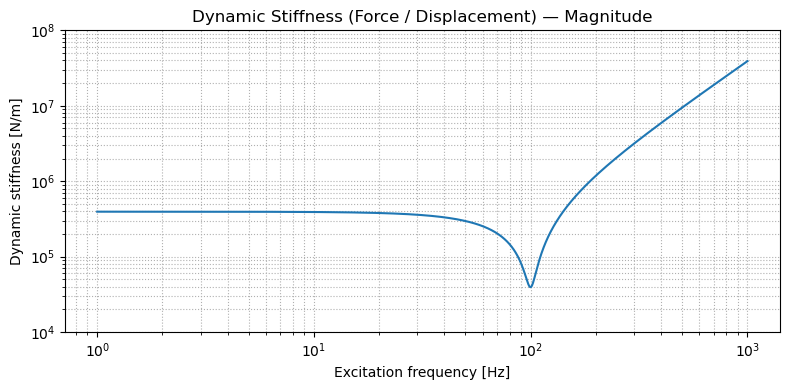

In [29]:
plot_frf_pair(
    f,
    Kd,
    title="Dynamic Stiffness (Force / Displacement)",
    ylabel_mag="Dynamic stiffness [N/m]",
    phase_ylim=(175, 365),
    mag_ylim=(1e4, 1e8),
    phase_convention="lag"
)

## 12. Mechanical Impedance


La **mechanical impedance** es:

$
\frac{F(\omega)}{V(\omega)}
$

Unidad:

$
N/(m/s)
$

Es la inversa de la movilidad.

Esta función es muy usada para estudiar interacción fuerza–velocidad en sistemas mecánicos.

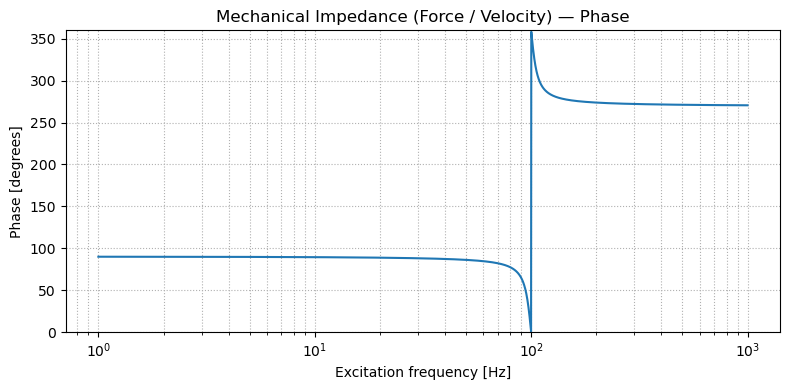

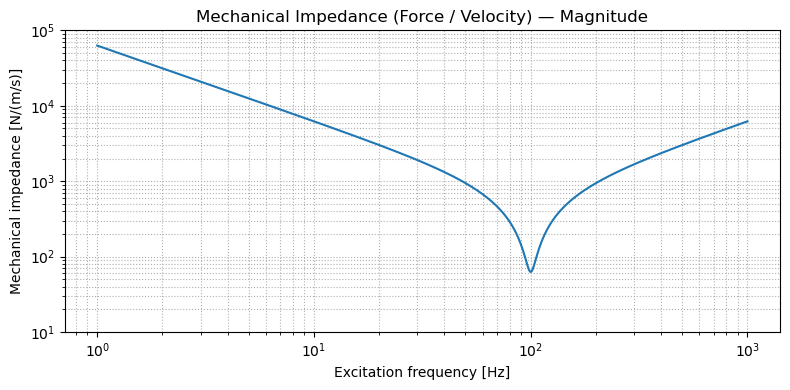

In [30]:
plot_frf_pair(
    f,
    Z,
    title="Mechanical Impedance (Force / Velocity)",
    ylabel_mag="Mechanical impedance [N/(m/s)]",
    phase_ylim=(0, 360),
    mag_ylim=(1e1, 1e5),
    phase_convention="lag"
)

## 13. Apparent Mass


La **apparent mass** es:

$
\frac{F(\omega)}{A(\omega)}
$

Unidad:

$
kg
$

Es la inversa de la acelerancia.

En alta frecuencia, para este sistema ideal, tiende aproximadamente a la masa física del sistema.

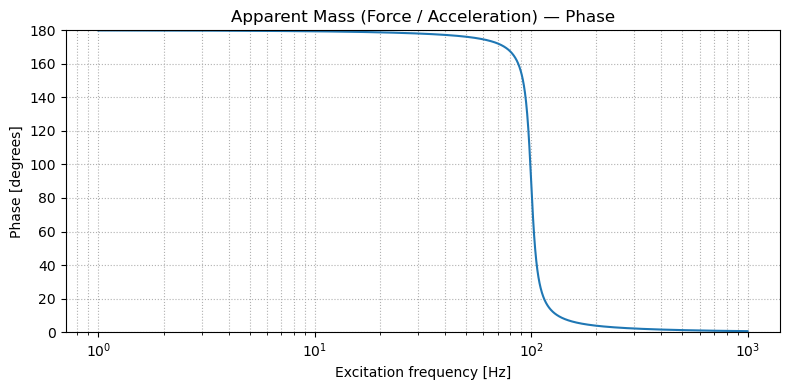

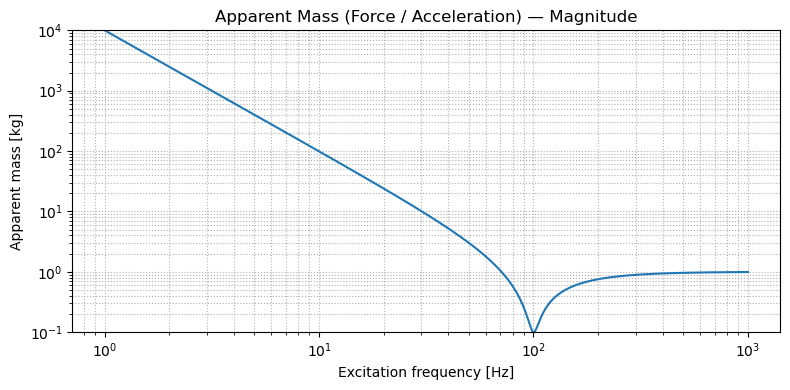

In [31]:
plot_frf_pair(
    f,
    Ma,
    title="Apparent Mass (Force / Acceleration)",
    ylabel_mag="Apparent mass [kg]",
    phase_ylim=(0, 180),
    mag_ylim=(1e-1, 1e4),
    phase_convention="lag"
)

## 14. Comparación directa de magnitudes

Ahora podemos comparar las tres FRF directas:

- \(X/F\): receptancia
- \(V/F\): movilidad
- \(A/F\): acelerancia

Estas tres funciones están relacionadas por derivación en el dominio de la frecuencia.

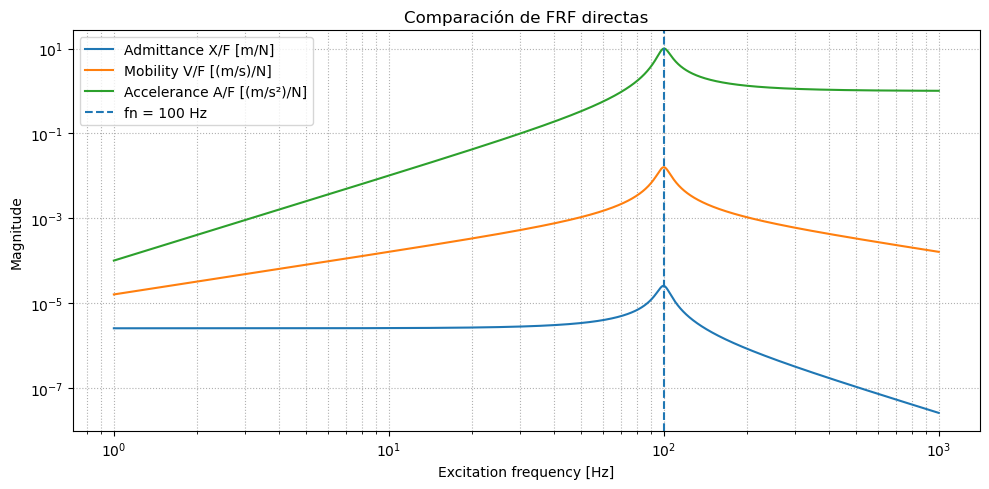

In [32]:
plt.figure(figsize=(10, 5))
plt.loglog(f, np.abs(Hx), label="Admittance X/F [m/N]")
plt.loglog(f, np.abs(Hv), label="Mobility V/F [(m/s)/N]")
plt.loglog(f, np.abs(Ha), label="Accelerance A/F [(m/s²)/N]")
plt.axvline(fn, linestyle="--", label=f"fn = {fn:.0f} Hz")
plt.title("Comparación de FRF directas")
plt.xlabel("Excitation frequency [Hz]")
plt.ylabel("Magnitude")
plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

## 15. Comparación directa de inversas

Ahora comparamos:

- \(F/X\): rigidez dinámica
- \(F/V\): impedancia mecánica
- \(F/A\): masa aparente

Estas funciones también contienen información modal, pero vista desde la perspectiva inversa.

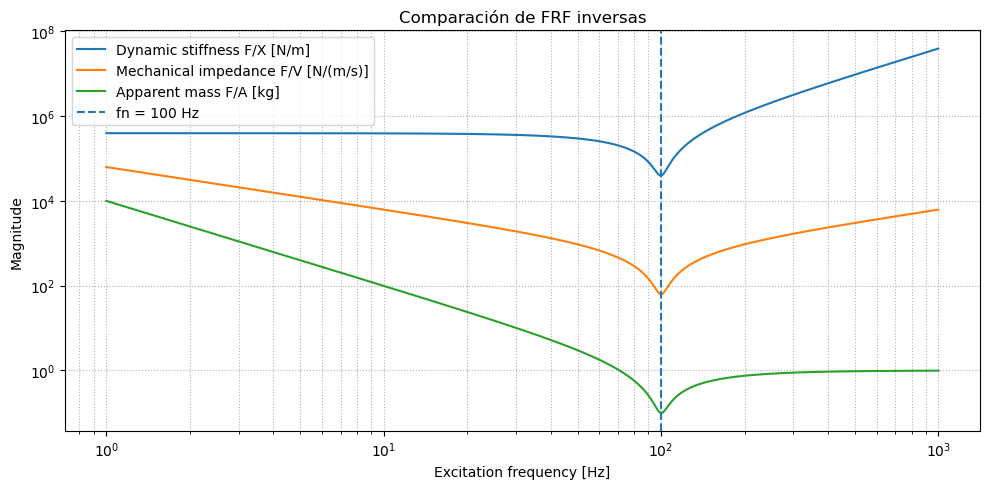

In [33]:
plt.figure(figsize=(10, 5))
plt.loglog(f, np.abs(Kd), label="Dynamic stiffness F/X [N/m]")
plt.loglog(f, np.abs(Z), label="Mechanical impedance F/V [N/(m/s)]")
plt.loglog(f, np.abs(Ma), label="Apparent mass F/A [kg]")
plt.axvline(fn, linestyle="--", label=f"fn = {fn:.0f} Hz")
plt.title("Comparación de FRF inversas")
plt.xlabel("Excitation frequency [Hz]")
plt.ylabel("Magnitude")
plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

## 16. Interpretación física

### Receptancia \(X/F\)

Indica cuánto se desplaza el sistema frente a una fuerza aplicada.

### Movilidad \(V/F\)

Indica cuánta velocidad se genera frente a una fuerza aplicada.

### Acelerancia \(A/F\)

Indica cuánta aceleración se produce frente a una fuerza aplicada.

### Rigidez dinámica \(F/X\)

Indica cuánta fuerza se requiere para producir un desplazamiento a cada frecuencia.

### Impedancia mecánica \(F/V\)

Indica cuánta fuerza se requiere para producir velocidad.

### Masa aparente \(F/A\)

Indica la masa efectiva observada dinámicamente por la fuerza aplicada.

## 17. Preguntas para discusión

1. ¿Por qué la receptancia presenta un máximo cerca de la frecuencia natural?
2. ¿Por qué la rigidez dinámica presenta un mínimo cerca de la frecuencia natural?
3. ¿Qué diferencia conceptual existe entre receptancia, movilidad y acelerancia?
4. ¿Por qué la masa aparente tiende a un valor cercano a la masa física en alta frecuencia?
5. ¿Cuál de estas FRF sería más útil si en laboratorio medimos aceleración con un acelerómetro?
6. ¿Cuál sería más útil si medimos fuerza y desplazamiento?

## 18. Cierre

Las funciones de respuesta en frecuencia permiten estudiar cómo un sistema responde a una excitación armónica en función de la frecuencia.

La idea central es:

$
\text{respuesta} = \text{FRF} \times \text{excitación}
$

o, en el caso de desplazamiento:

$
X(\omega)=H_x(\omega)F(\omega)
$

Las distintas FRF entregan diferentes miradas del mismo sistema físico.